In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/stock_features.csv")

df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Date,Close,High,Low,Open,Volume,Stock,Year,Month,Quarter,Day,Daily_Return,Volatility,MA50,MA200,Cumulative_Return,Avg_Volume_30,Annualized_Volatility,Sharpe_Ratio
0,2020-10-15,117.085510,117.560795,114.602380,115.155265,112559200,AAPL,2020,10,4,15,-0.003961,0.032251,113.408251,85.723244,1.618681,1.702805e+08,0.511976,0.034192
1,2020-10-16,115.446251,117.900290,115.242557,117.638393,115393800,AAPL,2020,10,4,16,-0.014001,0.028834,113.511505,85.938806,1.596019,1.655403e+08,0.457733,0.038244
2,2020-10-19,112.497543,116.804221,112.187152,116.358034,120639300,AAPL,2020,10,4,19,-0.025542,0.029205,113.605932,86.143140,1.555254,1.584747e+08,0.463610,0.037759
3,2020-10-20,113.981613,115.407476,112.158058,112.710943,124423700,AAPL,2020,10,4,20,0.013192,0.026472,113.698710,86.352041,1.575771,1.549099e+08,0.420236,0.041656
4,2020-10-21,113.360809,115.145557,112.953415,113.166810,89946000,AAPL,2020,10,4,21,-0.005447,0.025493,113.844109,86.559536,1.567188,1.520101e+08,0.404688,0.043257


In [4]:
df.describe()


,Date,Close,High,Low,Open,Volume,Year,Month,Quarter,Day,Daily_Return,Volatility,MA50,MA200,Cumulative_Return,Avg_Volume_30,Annualized_Volatility,Sharpe_Ratio
count,6354,6354.000000,6354.000000,6354.000000,6354.000000,6.354000e+03,6354.000000,6354.000000,6354.000000,6354.000000,6354.000000,6354.000000,6354.000000,6354.000000,6354.000000,6.354000e+03,6354.000000,6354.000000
mean,2022-11-22 22:35:41.643059,171.781216,174.079096,169.358345,171.758902,1.214280e+08,2022.372049,6.785647,2.590179,15.757318,0.001240,0.023341,168.347143,159.044896,3.908108,1.228836e+08,0.370529,0.070969
min,2020-10-15 00:00:00,11.212298,11.719631,10.798839,10.956632,7.164500e+06,2020.000000,1.000000,1.000000,1.000000,-0.140494,0.007441,12.725339,8.955594,0.862166,1.728997e+07,0.118119,0.019581
25%,2021-11-02 00:00:00,116.879681,118.487802,115.209071,117.043053,3.161768e+07,2021.000000,4.000000,2.000000,8.000000,-0.011311,0.014965,115.499072,106.618675,1.744214,3.246052e+07,0.237560,0.049450
50%,2022-11-21 00:00:00,161.488747,163.172730,159.584068,161.498029,5.982570e+07,2022.000000,7.000000,3.000000,16.000000,0.001175,0.020528,159.406540,152.295934,2.174046,6.489640e+07,0.325877,0.065856
75%,2023-12-12 00:00:00,226.151279,229.729708,222.989664,226.293691,1.117288e+08,2023.000000,10.000000,4.000000,23.000000,0.013340,0.029829,224.704901,210.256375,4.084949,1.073641e+08,0.473513,0.085819
max,2024-12-31 00:00:00,479.859985,488.540009,457.510010,475.899994,1.543911e+09,2024.000000,12.000000,4.000000,31.000000,0.243696,0.064657,432.388093,418.915132,24.924992,6.426504e+08,1.026392,0.232976
std,NaN,95.365948,96.563060,94.100515,95.395566,1.599235e+08,1.221333,3.496981,1.135051,8.761957,0.025592,0.010680,92.615968,88.233512,3.996755,1.502008e+08,0.169542,0.029835


In [5]:
df.groupby('Stock')[
    ['Daily_Return',
     'Volatility',
     'Sharpe_Ratio']
].mean()

,Daily_Return,Volatility,Sharpe_Ratio
Stock,,,
AAPL,0.000852,0.016461,0.073633
AMZN,0.000495,0.021013,0.045017
GOOGL,0.001025,0.018644,0.055177
MSFT,0.000780,0.015875,0.062534
NVDA,0.002667,0.031619,0.102585
TSLA,0.001622,0.036434,0.086868


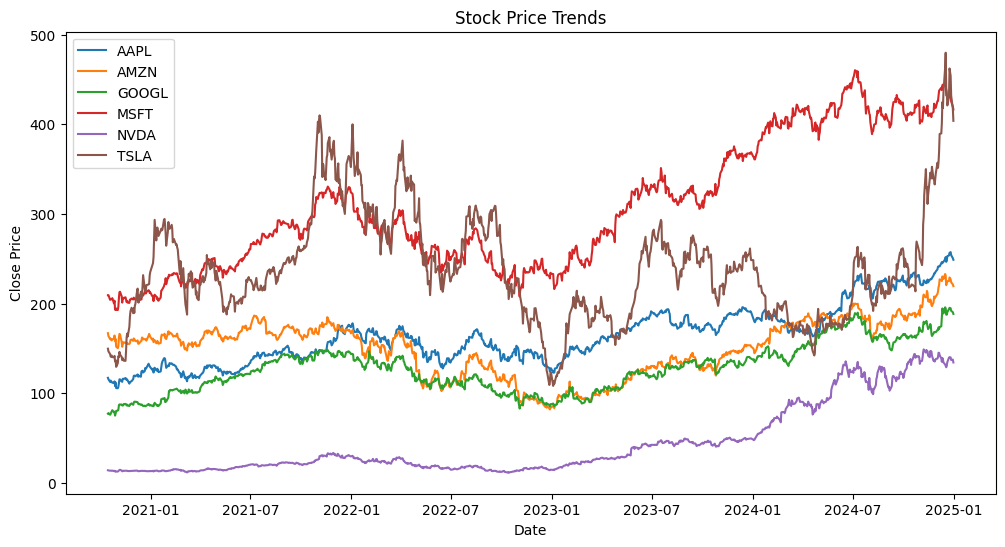

In [6]:
# Analyzing Closing Price Trend

plt.figure(figsize=(12,6))

for stock in df['Stock'].unique():

    temp = df[df['Stock']==stock]

    plt.plot(temp['Date'],temp['Close'],label=stock)

plt.xlabel("Date")

plt.ylabel("Close Price")

plt.title("Stock Price Trends")

plt.legend()

plt.show()

In [10]:
#Insights => NVDA shows strongest growth trajectory

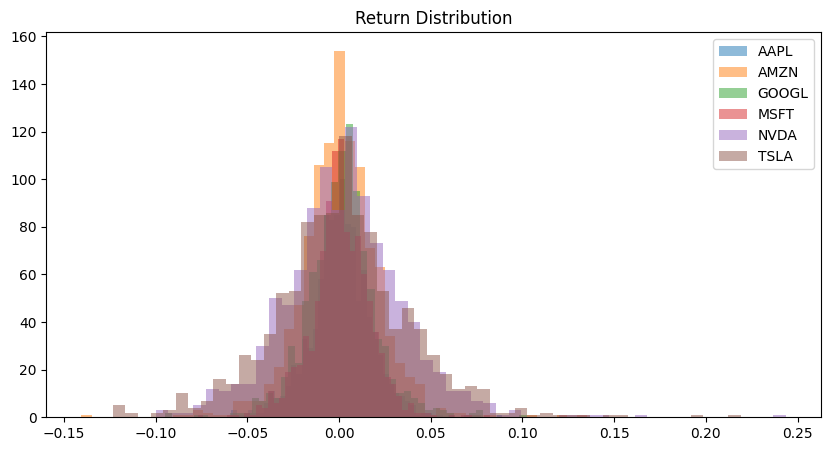

In [7]:
# Daily Return Distribution
# Large Spread => High risk

plt.figure(figsize=(10,5))

for stock in df['Stock'].unique():

    temp = df[df['Stock']==stock]

    plt.hist(temp['Daily_Return'],bins=50,alpha=.5,label=stock)

plt.legend()

plt.title("Return Distribution")

plt.show()

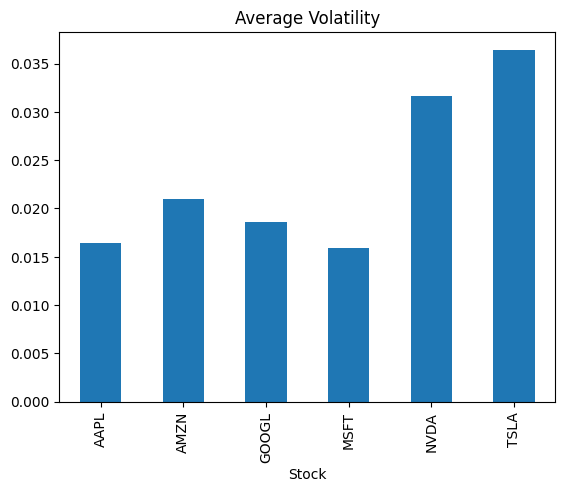

In [12]:
#Volatility Comparision
# High volatility => High Risk

avg_vol = (df.groupby('Stock')['Volatility'].mean())

avg_vol.plot(kind='bar')

plt.title("Average Volatility")

plt.show()

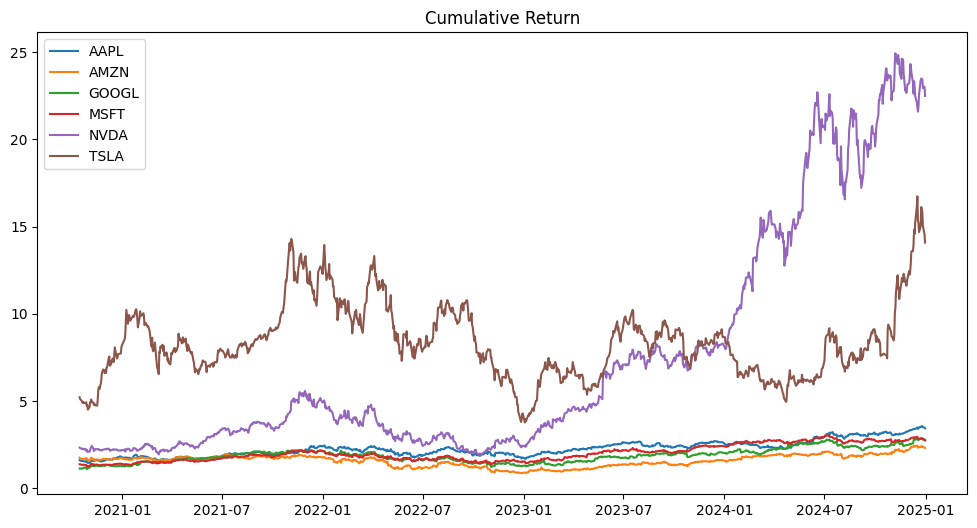

In [8]:
#Cumulative Return Trend

plt.figure(figsize=(12,6))

for stock in df['Stock'].unique():

    temp = df[df['Stock']==stock]

    plt.plot(temp['Date'],temp['Cumulative_Return'],label=stock)

plt.legend()

plt.title("Cumulative Return")

plt.show()

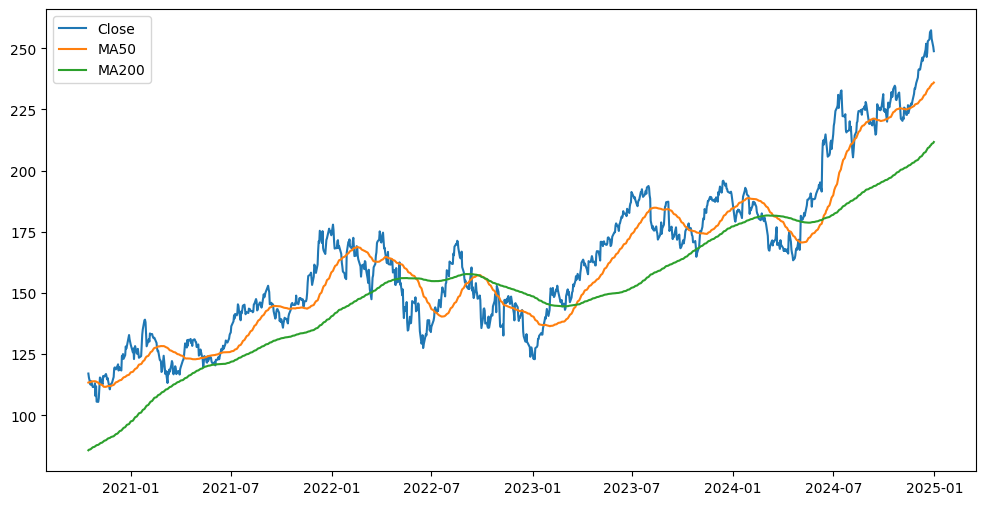

In [9]:
#Moving Average Analysis

stock='AAPL'

temp=df[df['Stock']==stock]

plt.figure(figsize=(12,6))

plt.plot(temp['Date'],temp['Close'])

plt.plot(temp['Date'],temp['MA50'])

plt.plot(temp['Date'],temp['MA200'])

plt.legend(['Close','MA50','MA200'])

plt.show()

In [10]:
# Correlation heatmap

returns = df.pivot(index='Date',columns='Stock',values='Daily_Return')

corr = returns.corr()

corr

Stock,AAPL,AMZN,GOOGL,MSFT,NVDA,TSLA
Stock,,,,,,
AAPL,1.000000,0.569962,0.594462,0.678150,0.546175,0.470555
AMZN,0.569962,1.000000,0.630797,0.676319,0.560056,0.419553
GOOGL,0.594462,0.630797,1.000000,0.698691,0.534918,0.364098
MSFT,0.678150,0.676319,0.698691,1.000000,0.631781,0.399455
NVDA,0.546175,0.560056,0.534918,0.631781,1.000000,0.446475
TSLA,0.470555,0.419553,0.364098,0.399455,0.446475,1.000000


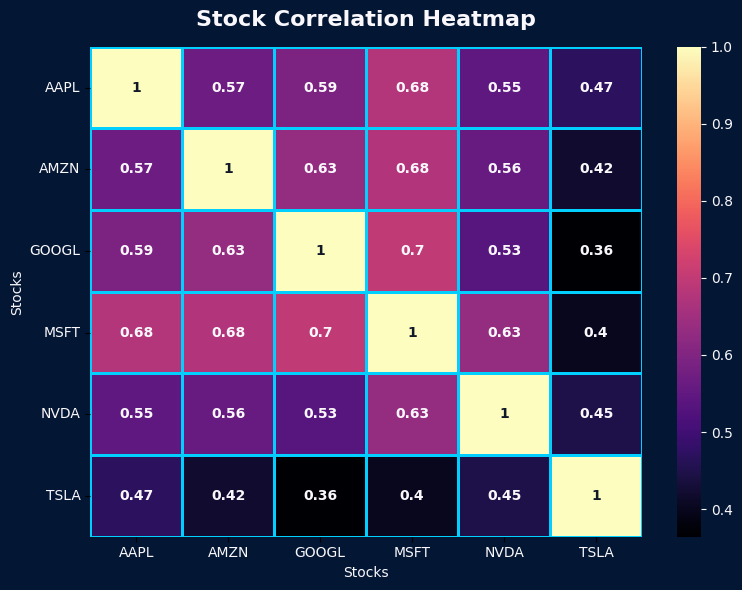

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(
    figsize=(8,6),
    facecolor='#06122a'
)

# Create heatmap
ax = sns.heatmap(

    corr,

    annot=True,

    cmap='magma',

    linewidths=1,

    linecolor='#00CFFF',

    annot_kws={
        "color":"#faf8fc",
        "size":12,
        "weight":"semibold"
    },

    cbar=True
)

# Dynamic annotation colors
for text in ax.texts:

    value = float(text.get_text())

    if value >= 0.9:
        text.set_color('#111827')     # dark text for bright cells
    else:
        text.set_color('#faf8fc')   # white text for dark cells

    text.set_fontsize(10)
    text.set_weight('semibold')

# Background colors
ax.set_facecolor('#111827')

# Title
plt.title(

    "Stock Correlation Heatmap",

    fontsize=16,

    color='#faf8fc',

    weight='semibold',

    pad=15
)

# label colors

plt.xlabel("Stocks",color='#faf8fc')
plt.ylabel("Stocks",color='#faf8fc')

# Tick colors
plt.xticks(color='#faf8fc',rotation=0)

plt.yticks( color='#faf8fc',rotation=0)

# Color bar styling
cbar = ax.collections[0].colorbar

cbar.ax.yaxis.set_tick_params(
    color='#faf8fc'
)

plt.setp(
    plt.getp(cbar.ax.axes, 'yticklabels'),
    color='#faf8fc'
)

# Tight layout
plt.tight_layout()

# Save image
plt.savefig(

    "../screenshots/heatmap.png",

    dpi=300,

    bbox_inches='tight',

    facecolor='#111827'
)

# Show
plt.show()

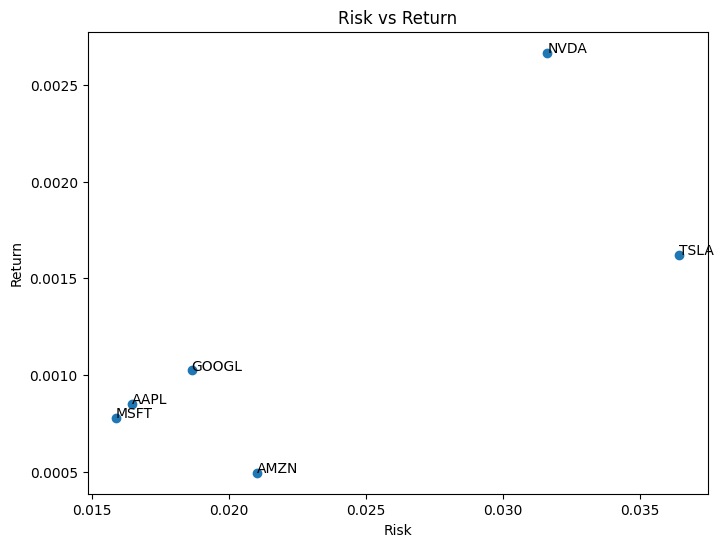

In [18]:
#Risk vs Return scatter plot

summary = (df.groupby('Stock').agg({'Daily_Return':'mean','Volatility':'mean'}))

plt.figure(figsize=(8,6))

plt.scatter(summary['Volatility'],summary['Daily_Return'])

for i in summary.index:

    plt.text(summary.loc[i,'Volatility'],summary.loc[i,'Daily_Return'],i)

plt.xlabel("Risk")

plt.ylabel("Return")

plt.title("Risk vs Return")

plt.show()

In [18]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock', 'Year',
       'Month', 'Quarter', 'Day', 'Daily_Return', 'Volatility', 'MA50',
       'MA200', 'Cumulative_Return', 'Avg_Volume_30', 'Annualized_Volatility',
       'Sharpe_Ratio'],
      dtype='str')

In [19]:
df.head()

,Date,Close,High,Low,Open,Volume,Stock,Year,Month,Quarter,Day,Daily_Return,Volatility,MA50,MA200,Cumulative_Return,Avg_Volume_30,Annualized_Volatility,Sharpe_Ratio
0,2020-10-15,117.085510,117.560795,114.602380,115.155265,112559200,AAPL,2020,10,4,15,-0.003961,0.032251,113.408251,85.723244,1.618681,1.702805e+08,0.511976,0.034192
1,2020-10-16,115.446251,117.900290,115.242557,117.638393,115393800,AAPL,2020,10,4,16,-0.014001,0.028834,113.511505,85.938806,1.596019,1.655403e+08,0.457733,0.038244
2,2020-10-19,112.497543,116.804221,112.187152,116.358034,120639300,AAPL,2020,10,4,19,-0.025542,0.029205,113.605932,86.143140,1.555254,1.584747e+08,0.463610,0.037759
3,2020-10-20,113.981613,115.407476,112.158058,112.710943,124423700,AAPL,2020,10,4,20,0.013192,0.026472,113.698710,86.352041,1.575771,1.549099e+08,0.420236,0.041656
4,2020-10-21,113.360809,115.145557,112.953415,113.166810,89946000,AAPL,2020,10,4,21,-0.005447,0.025493,113.844109,86.559536,1.567188,1.520101e+08,0.404688,0.043257


In [20]:
# Insights 

# 1. NVDA generated highest cumulative return.

# 2. TSLA exhibited highest volatility.

# 3. MSFT maintained lower volatility with stable returns.

# 4. AAPL showed strong risk-adjusted performance.



In [7]:
print(df.shape[0])

6354
